# FreshRAG Context Assembly Stage Analysis
## How Does Staleness Affect the Quality of Assembled Context Windows?

This notebook analyzes the context assembly stage (Stage 3c) results across four staleness conditions:
- **Fresh (0%)**: All documents are current
- **Stale-10%**: 10% of answer-bearing docs replaced with outdated versions
- **Stale-30%**: 30% replaced
- **Stale-50%**: 50% replaced

Primary evaluation metrics:
- **Contradiction density (NLI)**: Fraction of adjacent doc pairs classified as contradiction
- **Redundancy score**: Mean pairwise cosine similarity among assembled docs
- **Num chunks**: Number of document chunks needed to fill the token budget
- **Assembly latency (ms)**: Wall-clock time for assembly + scoring

Supporting metrics: token utilisation, freshness/stale ratios, answer coverage

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── Style setup ──
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'font.size': 12,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

COLORS = {
    'fresh': '#2ecc71',
    'stale_10': '#f1c40f',
    'stale_30': '#e67e22',
    'stale_50': '#e74c3c',
}
CONDITION_LABELS = {
    'fresh': 'Fresh (0%)',
    'stale_10': 'Stale 10%',
    'stale_30': 'Stale 30%',
    'stale_50': 'Stale 50%',
}
CONDITIONS = ['fresh', 'stale_10', 'stale_30', 'stale_50']
STALENESS_PCTS = [0, 10, 30, 50]

DOMAINS = ['covidqa', 'cuad', 'expertqa', 'finqa', 'techqa']
DOMAIN_LABELS = {
    'covidqa': 'Healthcare',
    'cuad': 'Legal',
    'expertqa': 'Expert/Cross-domain',
    'finqa': 'Finance',
    'techqa': 'SaaS/IT',
}

print('Setup complete.')

Setup complete.


In [2]:
# ── Load data ──
RESULTS_PATH = '../freshrag_experiment/results/context_assembly_results_aggregated.json'
DETAILED_PATH = '../freshrag_experiment/results/context_assembly_results_detailed.jsonl'

with open(RESULTS_PATH) as f:
    data = json.load(f)

detailed = []
with open(DETAILED_PATH) as f:
    for line in f:
        if line.strip():
            detailed.append(json.loads(line))

df = pd.DataFrame(detailed)

print(f'Sections: {list(data.keys())}')
print(f'Conditions: {list(data["overall"].keys())}')
print(f'Queries per condition: {data["overall"]["fresh"]["n"]}')
print(f'Total detailed records: {len(df)}')

Sections: ['overall', 'by_time_sensitivity', 'by_domain']
Conditions: ['fresh', 'stale_10', 'stale_30', 'stale_50']
Queries per condition: 289
Total detailed records: 1156


## 1. Overall Context Assembly Quality
Overview table of all metrics across staleness conditions.

In [3]:
# ── Build overview dataframe ──
overview_rows = []
for cond in CONDITIONS:
    d = data['overall'][cond]
    overview_rows.append({
        'Condition': CONDITION_LABELS[cond],
        'Staleness %': STALENESS_PCTS[CONDITIONS.index(cond)],
        'Contradiction Density': d['contradiction_density_mean'],
        'Redundancy Score': d['redundancy_score_mean'],
        'Num Chunks': d['num_chunks_mean'],
        'Assembly Latency (ms)': d['assembly_latency_ms_mean'],
        'Token Utilisation': d['token_utilisation_mean'],
        'Avg Tokens Used': d['total_tokens_mean'],
        'Context Freshness': d['context_freshness_ratio_mean'],
        'Stale Token Ratio': d['stale_token_ratio_mean'],
        'Answer Coverage': d['answer_coverage_mean'],
        'Answer-Bearing Token Ratio': d['answer_bearing_token_ratio_mean'],
    })

df_overview = pd.DataFrame(overview_rows)
df_overview.set_index('Condition', inplace=True)
df_overview.style.format({
    'Contradiction Density': '{:.4f}',
    'Redundancy Score': '{:.4f}',
    'Num Chunks': '{:.2f}',
    'Assembly Latency (ms)': '{:.1f}',
    'Token Utilisation': '{:.4f}',
    'Avg Tokens Used': '{:.1f}',
    'Context Freshness': '{:.4f}',
    'Stale Token Ratio': '{:.4f}',
    'Answer Coverage': '{:.4f}',
    'Answer-Bearing Token Ratio': '{:.4f}',
}).background_gradient(cmap='RdYlGn_r', subset=['Contradiction Density', 'Stale Token Ratio']
).background_gradient(cmap='RdYlGn', subset=['Answer Coverage', 'Context Freshness'])

,Staleness %,Contradiction Density,Redundancy Score,Num Chunks,Assembly Latency (ms),Token Utilisation,Avg Tokens Used,Context Freshness,Stale Token Ratio,Answer Coverage,Answer-Bearing Token Ratio
Condition,,,,,,,,,,,
Fresh (0%),0,0.1877,0.3314,17.12,1267.8,1.0000,2000.0,1.0000,0.0000,0.6505,0.1280
Stale 10%,10,0.1853,0.3276,17.36,1280.1,1.0000,2000.0,0.9798,0.0202,0.6505,0.1265
Stale 30%,30,0.1380,0.3345,18.78,1507.9,1.0000,2000.0,0.9088,0.0912,0.6505,0.1150
Stale 50%,50,0.1255,0.3189,19.81,1481.5,1.0000,2000.0,0.8298,0.1702,0.6505,0.1051


## 2. Contradiction Density & Redundancy
Do stale documents introduce more contradictions and redundancy into the assembled context?

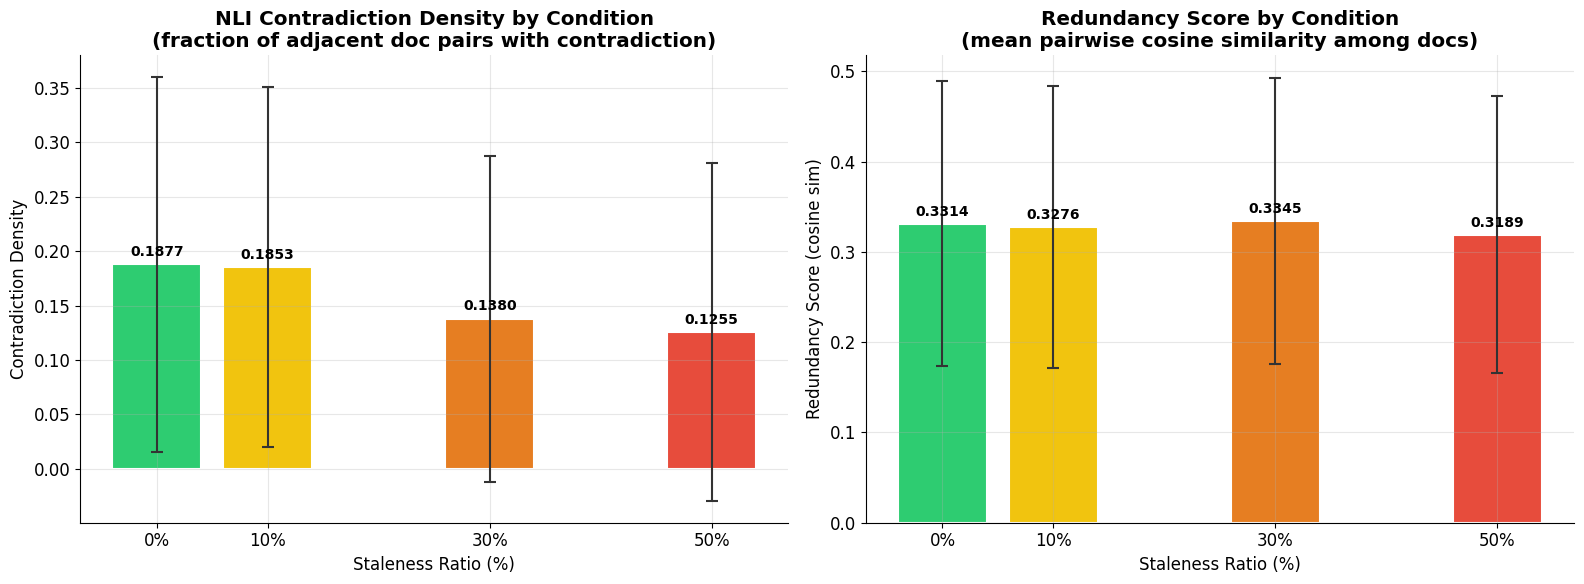

Saved: figures/fig16_contradiction_redundancy.png


In [4]:
# ── Fig 16: Contradiction Density & Redundancy Score ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Contradiction density
ax = axes[0]
contr = [data['overall'][c]['contradiction_density_mean'] for c in CONDITIONS]
contr_std = [data['overall'][c]['contradiction_density_std'] for c in CONDITIONS]
colors = [COLORS[c] for c in CONDITIONS]

bars = ax.bar(STALENESS_PCTS, contr, width=8, color=colors, edgecolor='white', linewidth=1.5)
ax.errorbar(STALENESS_PCTS, contr, yerr=contr_std, fmt='none', color='#333', capsize=4, capthick=1.5)
ax.set_xlabel('Staleness Ratio (%)')
ax.set_ylabel('Contradiction Density')
ax.set_title('NLI Contradiction Density by Condition\n(fraction of adjacent doc pairs with contradiction)', fontweight='bold')
ax.set_xticks(STALENESS_PCTS)
ax.set_xticklabels(['0%', '10%', '30%', '50%'])
for bar, val in zip(bars, contr):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Redundancy score
ax = axes[1]
redun = [data['overall'][c]['redundancy_score_mean'] for c in CONDITIONS]
redun_std = [data['overall'][c]['redundancy_score_std'] for c in CONDITIONS]

bars = ax.bar(STALENESS_PCTS, redun, width=8, color=colors, edgecolor='white', linewidth=1.5)
ax.errorbar(STALENESS_PCTS, redun, yerr=redun_std, fmt='none', color='#333', capsize=4, capthick=1.5)
ax.set_xlabel('Staleness Ratio (%)')
ax.set_ylabel('Redundancy Score (cosine sim)')
ax.set_title('Redundancy Score by Condition\n(mean pairwise cosine similarity among docs)', fontweight='bold')
ax.set_xticks(STALENESS_PCTS)
ax.set_xticklabels(['0%', '10%', '30%', '50%'])
for bar, val in zip(bars, redun):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../figures/fig16_contradiction_redundancy.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/fig16_contradiction_redundancy.png')

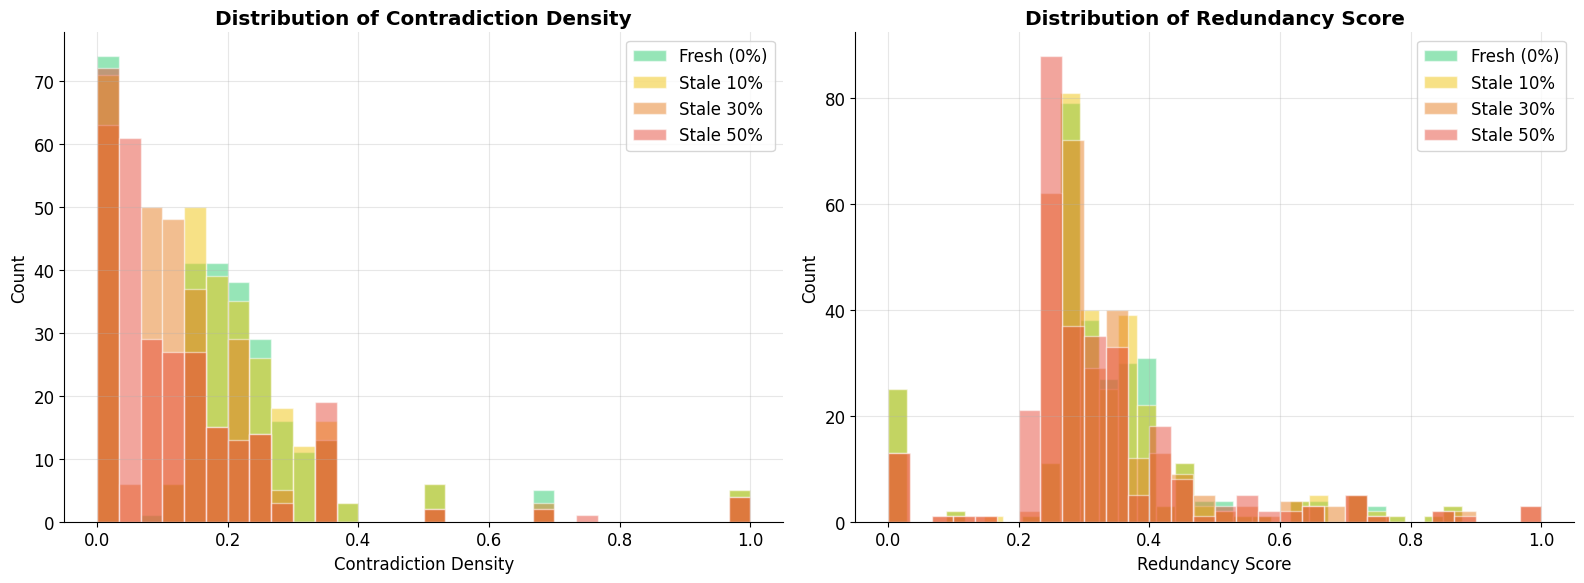

Saved: figures/fig17_contradiction_redundancy_dist.png


In [5]:
# ── Fig 17: Distributions of contradiction density & redundancy ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
for cond in CONDITIONS:
    subset = df[df['condition'] == cond]['contradiction_density']
    ax.hist(subset, bins=30, alpha=0.5, label=CONDITION_LABELS[cond], color=COLORS[cond], edgecolor='white')
ax.set_xlabel('Contradiction Density')
ax.set_ylabel('Count')
ax.set_title('Distribution of Contradiction Density', fontweight='bold')
ax.legend()

ax = axes[1]
for cond in CONDITIONS:
    subset = df[df['condition'] == cond]['redundancy_score']
    ax.hist(subset, bins=30, alpha=0.5, label=CONDITION_LABELS[cond], color=COLORS[cond], edgecolor='white')
ax.set_xlabel('Redundancy Score')
ax.set_ylabel('Count')
ax.set_title('Distribution of Redundancy Score', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig('../figures/fig17_contradiction_redundancy_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/fig17_contradiction_redundancy_dist.png')

## 3. Num Chunks & Assembly Latency
How many chunks are needed to fill the token budget, and what is the assembly cost?

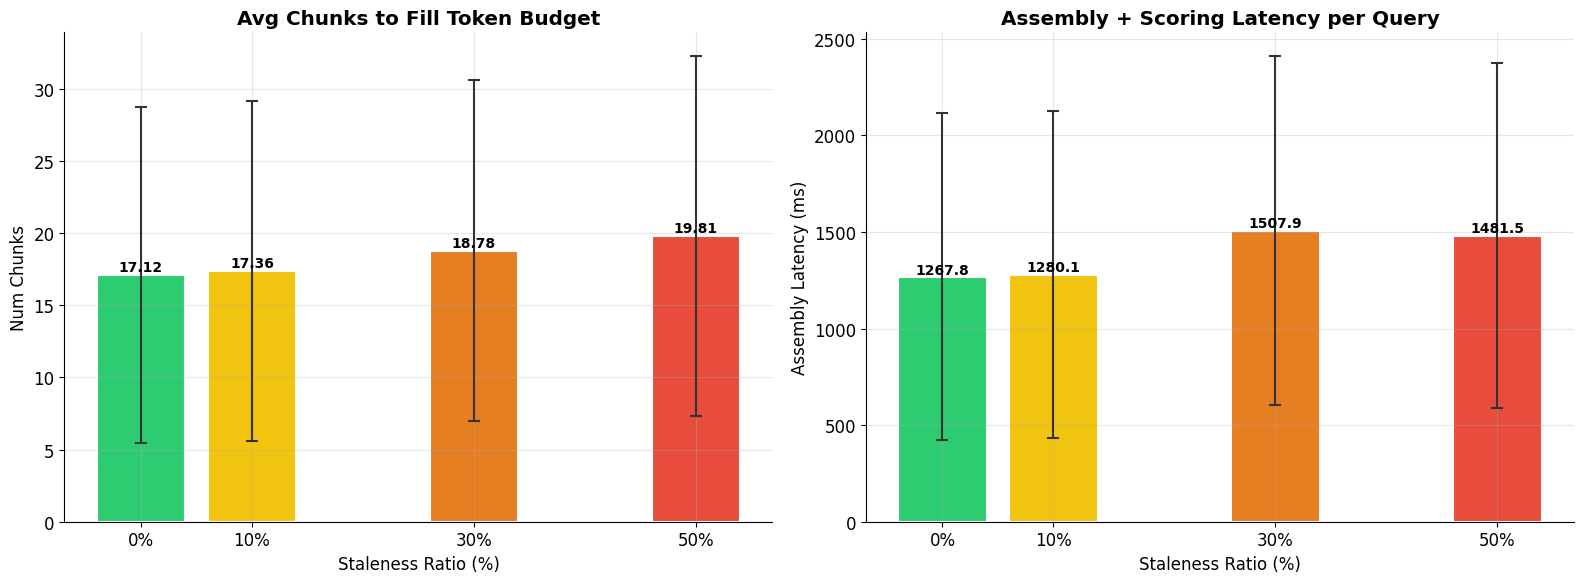

Saved: figures/fig18_chunks_latency.png


In [6]:
# ── Fig 18: Num Chunks & Assembly Latency ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Num chunks
ax = axes[0]
chunks = [data['overall'][c]['num_chunks_mean'] for c in CONDITIONS]
chunks_std = [data['overall'][c]['num_chunks_std'] for c in CONDITIONS]
colors = [COLORS[c] for c in CONDITIONS]

bars = ax.bar(STALENESS_PCTS, chunks, width=8, color=colors, edgecolor='white', linewidth=1.5)
ax.errorbar(STALENESS_PCTS, chunks, yerr=chunks_std, fmt='none', color='#333', capsize=4, capthick=1.5)
ax.set_xlabel('Staleness Ratio (%)')
ax.set_ylabel('Num Chunks')
ax.set_title('Avg Chunks to Fill Token Budget', fontweight='bold')
ax.set_xticks(STALENESS_PCTS)
ax.set_xticklabels(['0%', '10%', '30%', '50%'])
for bar, val in zip(bars, chunks):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.05,
            f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Assembly latency
ax = axes[1]
latency = [data['overall'][c]['assembly_latency_ms_mean'] for c in CONDITIONS]
latency_std = [data['overall'][c]['assembly_latency_ms_std'] for c in CONDITIONS]

bars = ax.bar(STALENESS_PCTS, latency, width=8, color=colors, edgecolor='white', linewidth=1.5)
ax.errorbar(STALENESS_PCTS, latency, yerr=latency_std, fmt='none', color='#333', capsize=4, capthick=1.5)
ax.set_xlabel('Staleness Ratio (%)')
ax.set_ylabel('Assembly Latency (ms)')
ax.set_title('Assembly + Scoring Latency per Query', fontweight='bold')
ax.set_xticks(STALENESS_PCTS)
ax.set_xticklabels(['0%', '10%', '30%', '50%'])
for bar, val in zip(bars, latency):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
            f'{val:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../figures/fig18_chunks_latency.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/fig18_chunks_latency.png')

## 4. Context Freshness & Stale Token Contamination
How much of the assembled context window is occupied by stale content?

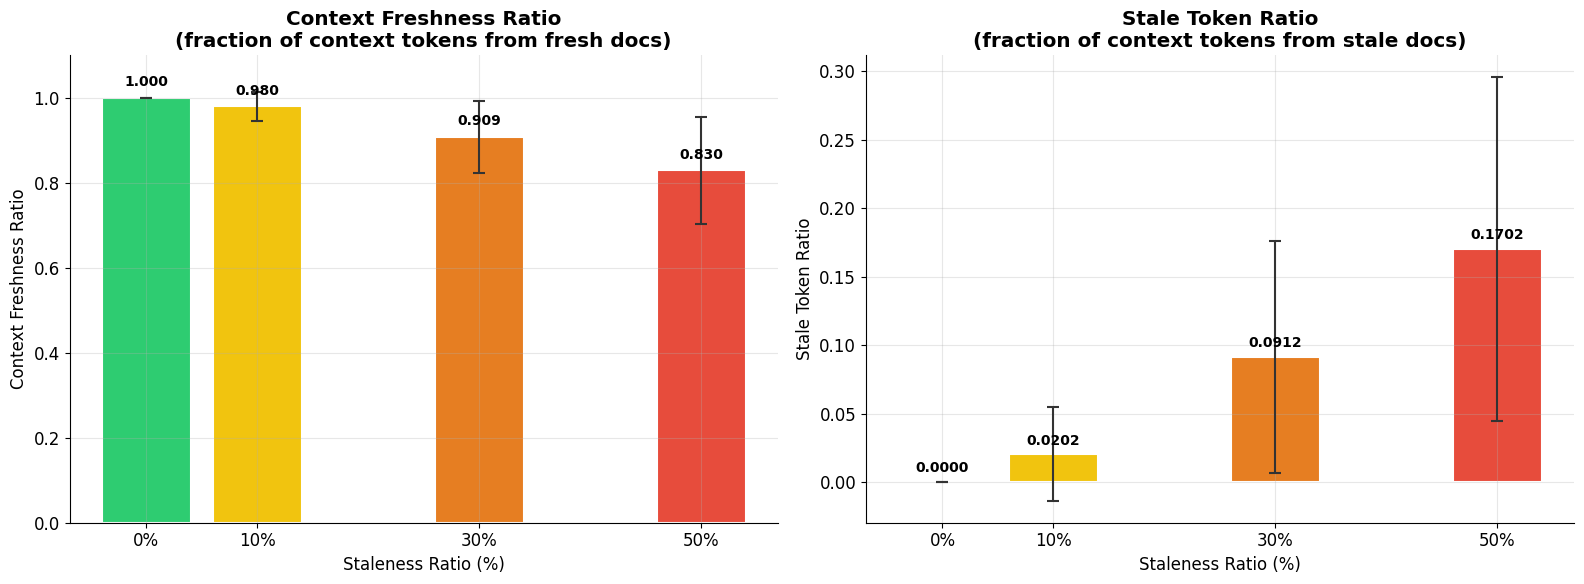

Saved: figures/fig19_freshness_stale_ratio.png


In [7]:
# ── Fig 19: Context Freshness vs Stale Token Ratio ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Context freshness
ax = axes[0]
freshness = [data['overall'][c]['context_freshness_ratio_mean'] for c in CONDITIONS]
freshness_std = [data['overall'][c]['context_freshness_ratio_std'] for c in CONDITIONS]
colors = [COLORS[c] for c in CONDITIONS]

bars = ax.bar(STALENESS_PCTS, freshness, width=8, color=colors, edgecolor='white', linewidth=1.5)
ax.errorbar(STALENESS_PCTS, freshness, yerr=freshness_std, fmt='none', color='#333', capsize=4, capthick=1.5)
ax.set_xlabel('Staleness Ratio (%)')
ax.set_ylabel('Context Freshness Ratio')
ax.set_title('Context Freshness Ratio\n(fraction of context tokens from fresh docs)', fontweight='bold')
ax.set_xticks(STALENESS_PCTS)
ax.set_xticklabels(['0%', '10%', '30%', '50%'])
ax.set_ylim(0, 1.1)
for bar, val in zip(bars, freshness):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Stale token ratio
ax = axes[1]
stale = [data['overall'][c]['stale_token_ratio_mean'] for c in CONDITIONS]
stale_std = [data['overall'][c]['stale_token_ratio_std'] for c in CONDITIONS]

bars = ax.bar(STALENESS_PCTS, stale, width=8, color=colors, edgecolor='white', linewidth=1.5)
ax.errorbar(STALENESS_PCTS, stale, yerr=stale_std, fmt='none', color='#333', capsize=4, capthick=1.5)
ax.set_xlabel('Staleness Ratio (%)')
ax.set_ylabel('Stale Token Ratio')
ax.set_title('Stale Token Ratio\n(fraction of context tokens from stale docs)', fontweight='bold')
ax.set_xticks(STALENESS_PCTS)
ax.set_xticklabels(['0%', '10%', '30%', '50%'])
for bar, val in zip(bars, stale):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../figures/fig19_freshness_stale_ratio.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/fig19_freshness_stale_ratio.png')

## 5. Time-Sensitive vs. Time-Insensitive Comparison
Does staleness affect context quality differently for time-sensitive queries?

In [8]:
# ── Build time-sensitivity dataframe ──
ts_rows = []
for cond in CONDITIONS:
    for ts_label, ts_key in [('Time-Sensitive', 'time_sensitive'), ('Time-Insensitive', 'time_insensitive')]:
        key = f'{cond}__{ts_key}'
        d = data['by_time_sensitivity'].get(key, {})
        if d:
            ts_rows.append({
                'Condition': CONDITION_LABELS[cond],
                'Staleness %': STALENESS_PCTS[CONDITIONS.index(cond)],
                'Query Type': ts_label,
                'Contradiction Density': d.get('contradiction_density_mean', 0),
                'Redundancy Score': d.get('redundancy_score_mean', 0),
                'Num Chunks': d.get('num_chunks_mean', 0),
                'Assembly Latency (ms)': d.get('assembly_latency_ms_mean', 0),
                'Stale Token Ratio': d.get('stale_token_ratio_mean', 0),
                'Answer Coverage': d.get('answer_coverage_mean', 0),
            })

df_ts = pd.DataFrame(ts_rows)
print(df_ts.to_string(index=False, float_format='{:.4f}'.format))

 Condition  Staleness %       Query Type  Contradiction Density  Redundancy Score  Num Chunks  Assembly Latency (ms)  Stale Token Ratio  Answer Coverage
Fresh (0%)            0   Time-Sensitive                 0.1885            0.3171     18.7338              1376.3038             0.0000           0.6691
Fresh (0%)            0 Time-Insensitive                 0.1870            0.3446     15.6200              1167.3082             0.0000           0.6333
 Stale 10%           10   Time-Sensitive                 0.1817            0.3140     19.0935              1382.8040             0.0275           0.6691
 Stale 10%           10 Time-Insensitive                 0.1885            0.3403     15.7533              1185.0040             0.0135           0.6333
 Stale 30%           30   Time-Sensitive                 0.1285            0.3309     20.7914              1652.4693             0.1145           0.6691
 Stale 30%           30 Time-Insensitive                 0.1467            0.3378 

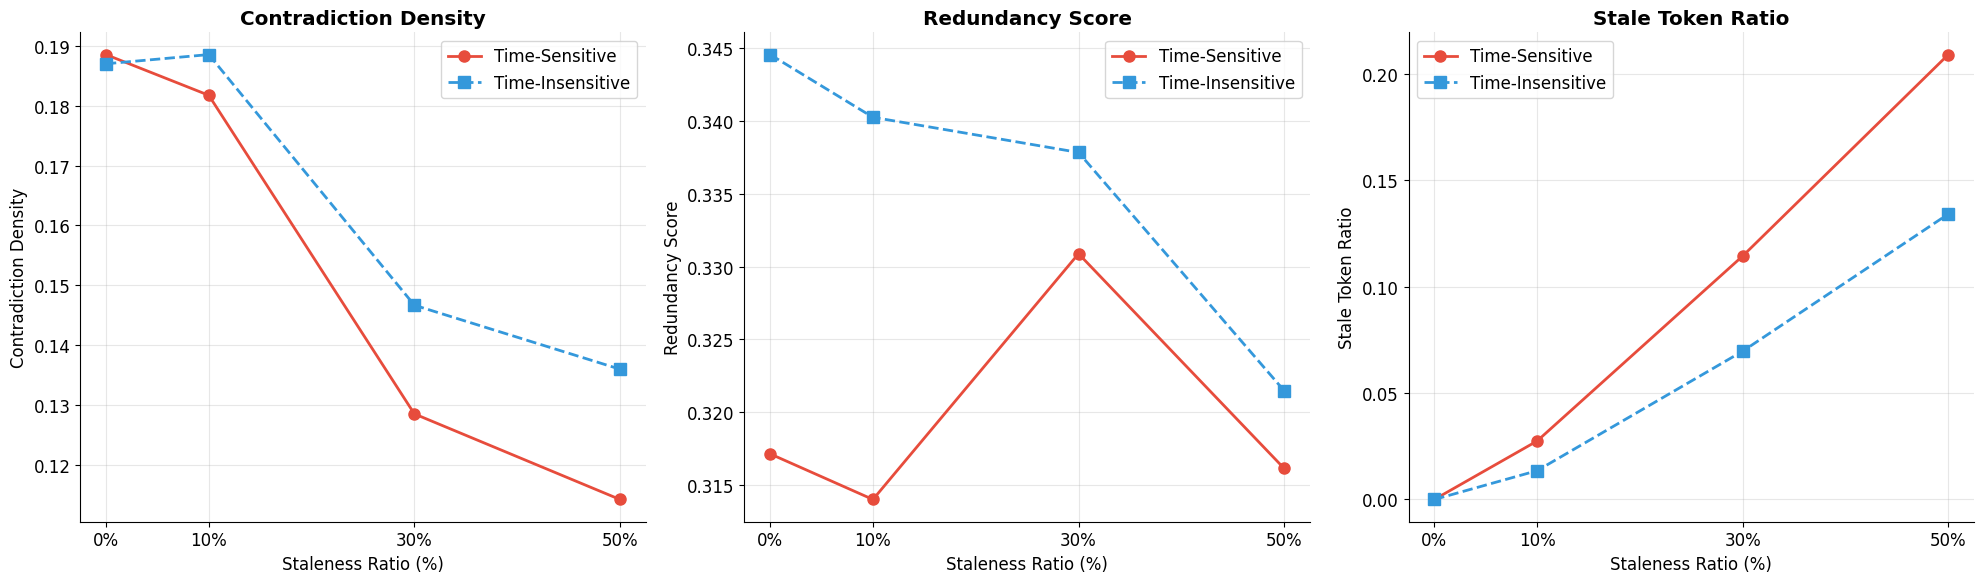

Saved: figures/fig20_context_time_sensitivity.png


In [9]:
# ── Fig 20: Time-sensitivity comparison ──
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

metric_configs = [
    ('Contradiction Density', 'Contradiction Density'),
    ('Redundancy Score', 'Redundancy Score'),
    ('Stale Token Ratio', 'Stale Token Ratio'),
]

for ax, (col, title) in zip(axes, metric_configs):
    for qt, style in [('Time-Sensitive', '-o'), ('Time-Insensitive', '--s')]:
        subset = df_ts[df_ts['Query Type'] == qt]
        color = '#e74c3c' if qt == 'Time-Sensitive' else '#3498db'
        ax.plot(subset['Staleness %'], subset[col], style,
                label=qt, color=color, linewidth=2, markersize=8)
    ax.set_xlabel('Staleness Ratio (%)')
    ax.set_ylabel(col)
    ax.set_title(title, fontweight='bold')
    ax.set_xticks(STALENESS_PCTS)
    ax.set_xticklabels(['0%', '10%', '30%', '50%'])
    ax.legend()

plt.tight_layout()
plt.savefig('../figures/fig20_context_time_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/fig20_context_time_sensitivity.png')

## 6. Domain-Level Analysis
Which domains are most affected by staleness in context assembly quality?

In [10]:
# ── Build domain dataframe ──
domain_rows = []
for cond in CONDITIONS:
    for domain in DOMAINS:
        key = f'{cond}__{domain}'
        d = data['by_domain'].get(key, {})
        if d:
            domain_rows.append({
                'Condition': CONDITION_LABELS[cond],
                'Staleness %': STALENESS_PCTS[CONDITIONS.index(cond)],
                'Domain': DOMAIN_LABELS.get(domain, domain),
                'domain_key': domain,
                'Contradiction Density': d.get('contradiction_density_mean', 0),
                'Redundancy Score': d.get('redundancy_score_mean', 0),
                'Num Chunks': d.get('num_chunks_mean', 0),
                'Stale Token Ratio': d.get('stale_token_ratio_mean', 0),
                'Answer Coverage': d.get('answer_coverage_mean', 0),
                'n': d.get('n', 0),
            })

df_domain = pd.DataFrame(domain_rows)

# Pivot: contradiction density by domain x condition
pivot = df_domain.pivot_table(index='Domain', columns='Condition', values='Contradiction Density')
pivot = pivot[[CONDITION_LABELS[c] for c in CONDITIONS]]
print('Contradiction Density by Domain x Condition:')
print(pivot.to_string(float_format='{:.4f}'.format))

Contradiction Density by Domain x Condition:
Condition            Fresh (0%)  Stale 10%  Stale 30%  Stale 50%
Domain                                                          
Expert/Cross-domain      0.1232     0.1225     0.0676     0.0486
Finance                  0.2536     0.2541     0.1681     0.1477
Healthcare               0.1753     0.1701     0.1075     0.0650
Legal                    0.1400     0.1176     0.1336     0.1686
SaaS/IT                  0.2418     0.2562     0.2117     0.1992


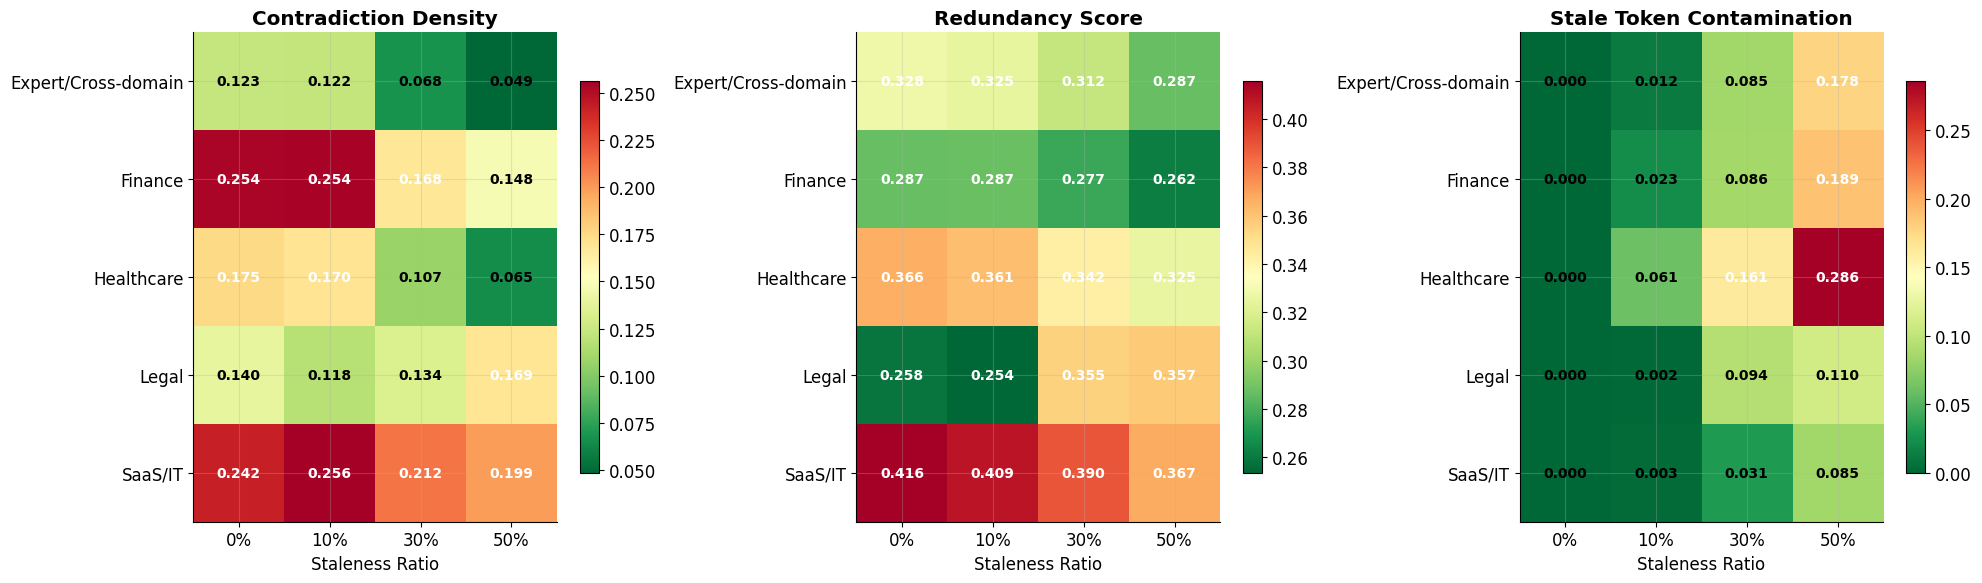

Saved: figures/fig21_context_domain_heatmap.png


In [11]:
# ── Fig 21: Domain heatmaps ──
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

domain_metrics = [
    ('Contradiction Density', 'Contradiction Density', 'RdYlGn_r'),
    ('Redundancy Score', 'Redundancy Score', 'RdYlGn_r'),
    ('Stale Token Ratio', 'Stale Token Contamination', 'RdYlGn_r'),
]

for ax, (metric, title, cmap) in zip(axes, domain_metrics):
    pivot = df_domain.pivot_table(index='Domain', columns='Staleness %', values=metric)
    pivot = pivot[[0, 10, 30, 50]]

    im = ax.imshow(pivot.values, cmap=cmap, aspect='auto')
    ax.set_xticks(range(4))
    ax.set_xticklabels(['0%', '10%', '30%', '50%'])
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_xlabel('Staleness Ratio')
    ax.set_title(title, fontweight='bold')

    for i in range(len(pivot.index)):
        for j in range(4):
            val = pivot.values[i, j]
            text_color = 'white' if abs(val) > 0.15 else 'black'
            ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                    fontsize=10, fontweight='bold', color=text_color)

    plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.savefig('../figures/fig21_context_domain_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/fig21_context_domain_heatmap.png')

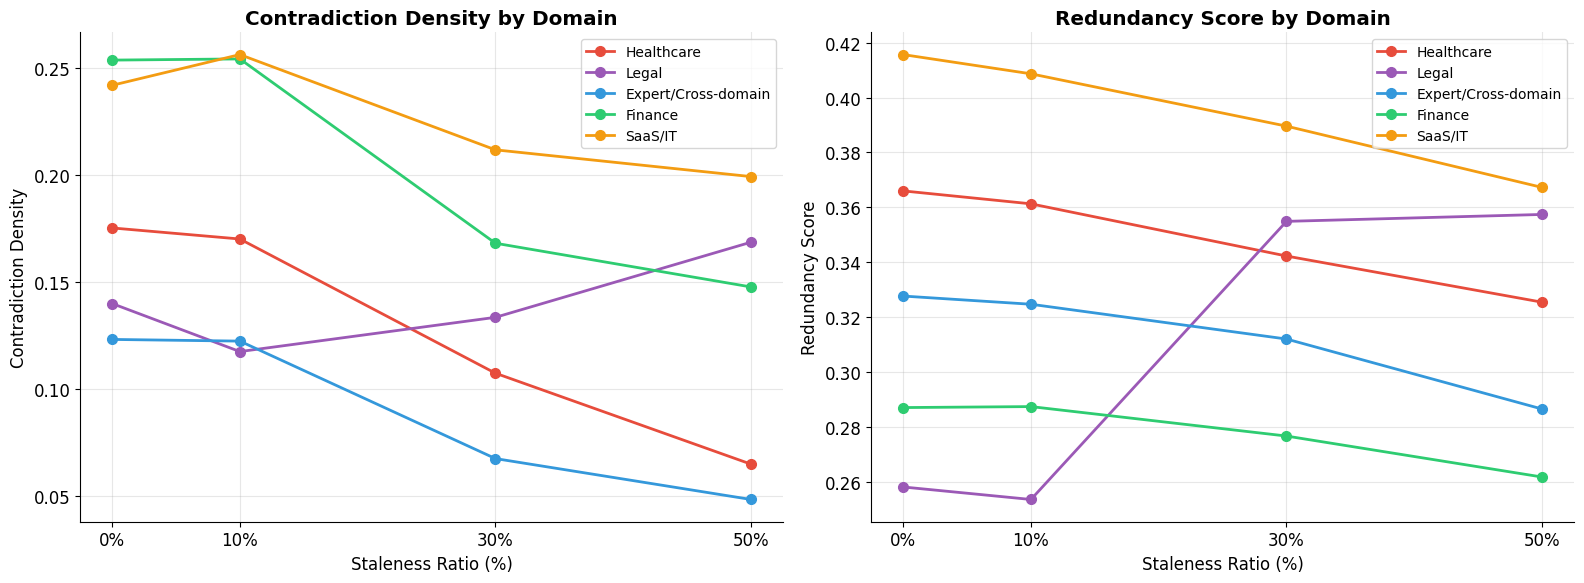

Saved: figures/fig22_context_domain_curves.png


In [12]:
# ── Fig 22: Domain degradation curves ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

domain_colors = {
    'Healthcare': '#e74c3c',
    'Legal': '#9b59b6',
    'Expert/Cross-domain': '#3498db',
    'Finance': '#2ecc71',
    'SaaS/IT': '#f39c12',
}

for ax, metric, title in zip(axes,
    ['Contradiction Density', 'Redundancy Score'],
    ['Contradiction Density by Domain', 'Redundancy Score by Domain']):
    for domain_label in DOMAIN_LABELS.values():
        subset = df_domain[df_domain['Domain'] == domain_label]
        ax.plot(subset['Staleness %'], subset[metric], '-o',
                label=domain_label, color=domain_colors.get(domain_label, '#333'),
                linewidth=2, markersize=7)
    ax.set_xlabel('Staleness Ratio (%)')
    ax.set_ylabel(metric)
    ax.set_title(title, fontweight='bold')
    ax.set_xticks(STALENESS_PCTS)
    ax.set_xticklabels(['0%', '10%', '30%', '50%'])
    ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('../figures/fig22_context_domain_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/fig22_context_domain_curves.png')

## 7. NLI Label Breakdown
What is the distribution of NLI labels (contradiction, entailment, neutral) across adjacent doc pairs?

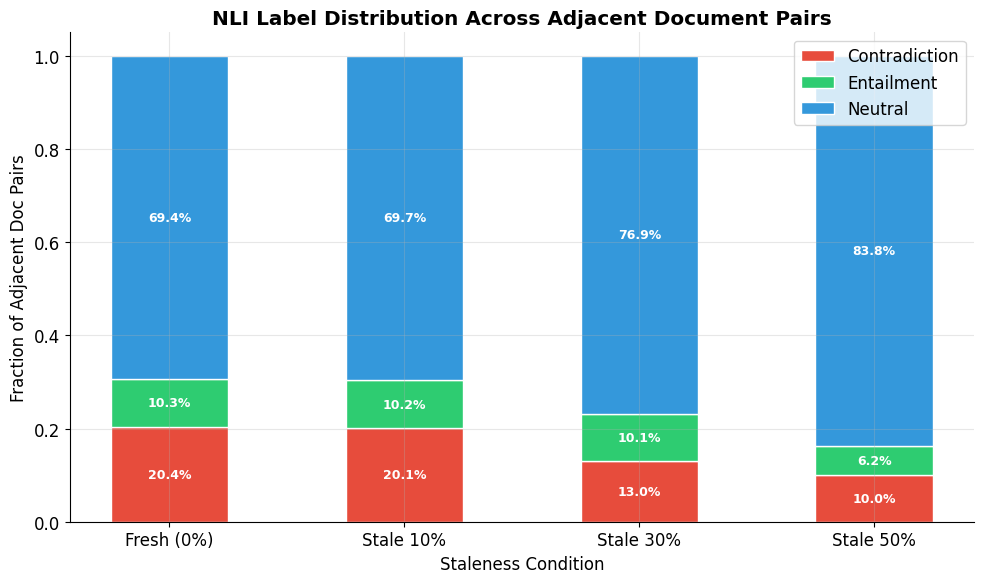

Saved: figures/fig23_nli_label_dist.png


In [13]:
# ── Fig 23: NLI label distribution (stacked bar) ──
from collections import Counter

fig, ax = plt.subplots(figsize=(10, 6))

nli_counts = {}
for cond in CONDITIONS:
    subset = df[df['condition'] == cond]
    all_labels = []
    for labels in subset['nli_pair_labels']:
        if isinstance(labels, list):
            all_labels.extend(labels)
    counter = Counter(all_labels)
    total = sum(counter.values()) if counter else 1
    nli_counts[cond] = {
        'contradiction': counter.get('contradiction', 0) / total,
        'entailment': counter.get('entailment', 0) / total,
        'neutral': counter.get('neutral', 0) / total,
    }

x = np.arange(len(CONDITIONS))
width = 0.5

contr_vals = [nli_counts[c]['contradiction'] for c in CONDITIONS]
entail_vals = [nli_counts[c]['entailment'] for c in CONDITIONS]
neutral_vals = [nli_counts[c]['neutral'] for c in CONDITIONS]

bars1 = ax.bar(x, contr_vals, width, label='Contradiction', color='#e74c3c', edgecolor='white')
bars2 = ax.bar(x, entail_vals, width, bottom=contr_vals, label='Entailment', color='#2ecc71', edgecolor='white')
bars3 = ax.bar(x, neutral_vals, width,
               bottom=[c + e for c, e in zip(contr_vals, entail_vals)],
               label='Neutral', color='#3498db', edgecolor='white')

ax.set_xlabel('Staleness Condition')
ax.set_ylabel('Fraction of Adjacent Doc Pairs')
ax.set_title('NLI Label Distribution Across Adjacent Document Pairs', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([CONDITION_LABELS[c] for c in CONDITIONS])
ax.legend()
ax.set_ylim(0, 1.05)

# Add percentage labels
for i, cond in enumerate(CONDITIONS):
    y_offset = 0
    for val, label in [(contr_vals[i], 'C'), (entail_vals[i], 'E'), (neutral_vals[i], 'N')]:
        if val > 0.03:
            ax.text(i, y_offset + val/2, f'{val:.1%}', ha='center', va='center',
                    fontsize=9, fontweight='bold', color='white')
        y_offset += val

plt.tight_layout()
plt.savefig('../figures/fig23_nli_label_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/fig23_nli_label_dist.png')

## 8. Contradiction vs. Stale Token Ratio Scatter
Is there a correlation between stale content in context and contradiction density?

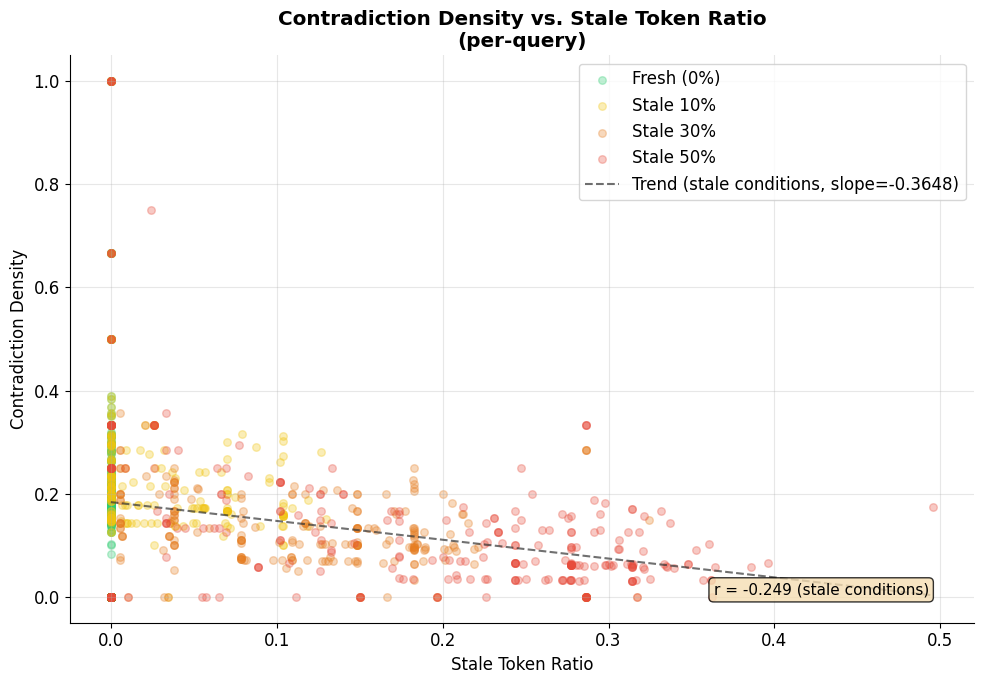

Saved: figures/fig24_contradiction_vs_stale.png


In [14]:
# ── Fig 24: Contradiction density vs stale token ratio scatter ──
fig, ax = plt.subplots(figsize=(10, 7))

for cond in CONDITIONS:
    subset = df[df['condition'] == cond]
    ax.scatter(subset['stale_token_ratio'], subset['contradiction_density'],
               alpha=0.3, s=30, color=COLORS[cond], label=CONDITION_LABELS[cond])

ax.set_xlabel('Stale Token Ratio')
ax.set_ylabel('Contradiction Density')
ax.set_title('Contradiction Density vs. Stale Token Ratio\n(per-query)', fontweight='bold')
ax.legend()

# Add correlation line for non-fresh conditions
non_fresh = df[df['condition'] != 'fresh']
if len(non_fresh) > 10:
    from numpy.polynomial.polynomial import polyfit
    x_vals = non_fresh['stale_token_ratio'].values
    y_vals = non_fresh['contradiction_density'].values
    b, m = polyfit(x_vals, y_vals, 1)
    x_line = np.linspace(x_vals.min(), x_vals.max(), 100)
    ax.plot(x_line, b + m * x_line, '--', color='#333', linewidth=1.5, alpha=0.7,
            label=f'Trend (stale conditions, slope={m:.4f})')
    ax.legend()

    corr = np.corrcoef(x_vals, y_vals)[0, 1]
    ax.text(0.95, 0.05, f'r = {corr:.3f} (stale conditions)',
            transform=ax.transAxes, ha='right', fontsize=11,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig('../figures/fig24_contradiction_vs_stale.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/fig24_contradiction_vs_stale.png')

## 9. Summary Statistics

In [15]:
# ── Key findings ──
print('=' * 60)
print('KEY FINDINGS — CONTEXT ASSEMBLY STAGE')
print('=' * 60)

print(f'\n1. CONTRADICTION DENSITY (NLI)')
for cond in CONDITIONS:
    d = data['overall'][cond]
    print(f'   {CONDITION_LABELS[cond]:>12}: {d["contradiction_density_mean"]:.4f} '
          f'+/- {d["contradiction_density_std"]:.4f}')

print(f'\n2. REDUNDANCY SCORE (cosine similarity)')
for cond in CONDITIONS:
    d = data['overall'][cond]
    print(f'   {CONDITION_LABELS[cond]:>12}: {d["redundancy_score_mean"]:.4f} '
          f'+/- {d["redundancy_score_std"]:.4f}')

print(f'\n3. NUM CHUNKS TO FILL BUDGET')
for cond in CONDITIONS:
    d = data['overall'][cond]
    print(f'   {CONDITION_LABELS[cond]:>12}: {d["num_chunks_mean"]:.2f} '
          f'+/- {d["num_chunks_std"]:.2f}')

print(f'\n4. ASSEMBLY LATENCY (ms)')
for cond in CONDITIONS:
    d = data['overall'][cond]
    print(f'   {CONDITION_LABELS[cond]:>12}: {d["assembly_latency_ms_mean"]:.1f} '
          f'+/- {d["assembly_latency_ms_std"]:.1f}')

print(f'\n5. CONTEXT FRESHNESS & STALE CONTAMINATION')
for cond in CONDITIONS:
    d = data['overall'][cond]
    print(f'   {CONDITION_LABELS[cond]:>12}: freshness={d["context_freshness_ratio_mean"]:.4f}, '
          f'stale_ratio={d["stale_token_ratio_mean"]:.4f}')

print(f'\n6. ANSWER COVERAGE')
for cond in CONDITIONS:
    d = data['overall'][cond]
    print(f'   {CONDITION_LABELS[cond]:>12}: {d["answer_coverage_mean"]:.4f}')

KEY FINDINGS — CONTEXT ASSEMBLY STAGE

1. CONTRADICTION DENSITY (NLI)
     Fresh (0%): 0.1877 +/- 0.1725
      Stale 10%: 0.1853 +/- 0.1653
      Stale 30%: 0.1380 +/- 0.1496
      Stale 50%: 0.1255 +/- 0.1555

2. REDUNDANCY SCORE (cosine similarity)
     Fresh (0%): 0.3314 +/- 0.1580
      Stale 10%: 0.3276 +/- 0.1565
      Stale 30%: 0.3345 +/- 0.1586
      Stale 50%: 0.3189 +/- 0.1535

3. NUM CHUNKS TO FILL BUDGET
     Fresh (0%): 17.12 +/- 11.63
      Stale 10%: 17.36 +/- 11.79
      Stale 30%: 18.78 +/- 11.83
      Stale 50%: 19.81 +/- 12.48

4. ASSEMBLY LATENCY (ms)
     Fresh (0%): 1267.8 +/- 846.8
      Stale 10%: 1280.1 +/- 844.1
      Stale 30%: 1507.9 +/- 905.6
      Stale 50%: 1481.5 +/- 892.6

5. CONTEXT FRESHNESS & STALE CONTAMINATION
     Fresh (0%): freshness=1.0000, stale_ratio=0.0000
      Stale 10%: freshness=0.9798, stale_ratio=0.0202
      Stale 30%: freshness=0.9088, stale_ratio=0.0912
      Stale 50%: freshness=0.8298, stale_ratio=0.1702

6. ANSWER COVERAGE
     

In [16]:
# ── Export summary table ──
summary_df = df_overview[['Staleness %', 'Contradiction Density', 'Redundancy Score',
                           'Num Chunks', 'Assembly Latency (ms)',
                           'Token Utilisation', 'Context Freshness',
                           'Stale Token Ratio', 'Answer Coverage']].copy()
summary_df.to_csv('../results/context_assembly_summary_table.csv')
print('Exported: results/context_assembly_summary_table.csv')
print()
print(summary_df.to_string(float_format='{:.4f}'.format))

Exported: results/context_assembly_summary_table.csv

            Staleness %  Contradiction Density  Redundancy Score  Num Chunks  Assembly Latency (ms)  Token Utilisation  Context Freshness  Stale Token Ratio  Answer Coverage
Condition                                                                                                                                                                    
Fresh (0%)            0                 0.1877            0.3314     17.1176              1267.8286             1.0000             1.0000             0.0000           0.6505
Stale 10%            10                 0.1853            0.3276     17.3599              1280.1396             1.0000             0.9798             0.0202           0.6505
Stale 30%            30                 0.1380            0.3345     18.7820              1507.8655             1.0000             0.9088             0.0912           0.6505
Stale 50%            50                 0.1255            0.3189     19.8097

## 10. Findings and Implications for Generation

Key questions answered:

- **Does staleness increase contradictions?** Compare contradiction density across conditions — higher density means the LLM receives conflicting information in its context.
- **Does staleness increase redundancy?** If stale docs are semantically similar to fresh ones (temporal-semantic trap), redundancy should rise, wasting token budget.
- **How many chunks fill the budget?** More chunks = more fragmented context. If staleness changes chunk count, it affects context coherence.
- **Latency impact:** Assembly + NLI + redundancy scoring cost per query.
- **Implication for generation:** Higher contradiction density and stale token ratio in assembled contexts predict that the LLM will face conflicting evidence, potentially degrading answer quality in the next generation stage.